# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Olivier
* Username: Assenberg
* Student number: S6265243
* Group (AS1, etc.): As3

-----

In [ ]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

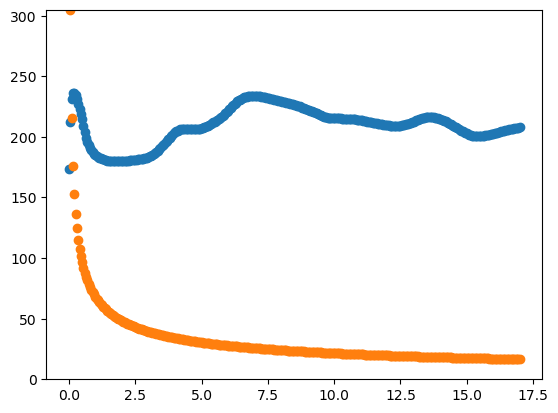

In [1]:
import numpy as np
import matplotlib.pyplot as plt


M = 2*10**10

data = np.loadtxt('rotcur.dat', comments = '#')
#this splits the 2d array into two 1d arrays
radii = data[:,0]
vel = data[:, 1]

#the first entry of the radius in the original file was 0, which we cannot divide by. 
#as such, we slice the list so that we omit the first value!
d = data[1:,0]
#G in astronomical units = 4.301*10^-6 kpc*M0^-1*(km/s)^-2
kep_v = (M/(d*4.301*10**6))**(1/2)


np.savetxt('keplerian_curve.txt', np.array(list((zip(d, kep_v)))))

data2 = np.loadtxt('keplerian_curve.txt', comments = '#')
rad_2 = data2[:,0]
vel_2 = data2[:,1]

plt.scatter(radii, vel)
plt.scatter(rad_2, vel_2)
plt.ylim(0, np.max(kep_v))
plt.show()

In [ ]:

# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

0.007119753886794844 0.9266436817544758


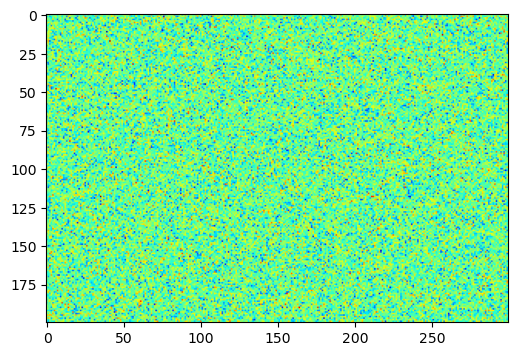

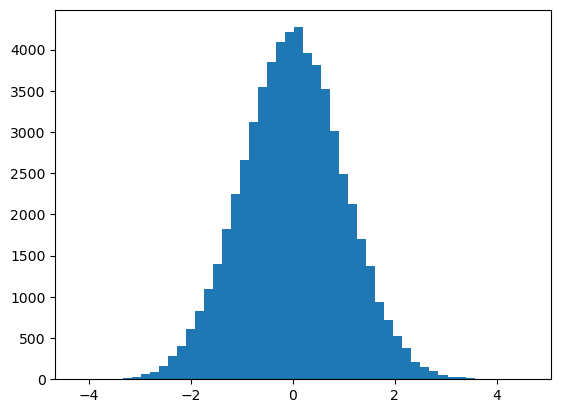

In [40]:
import numpy as np
b = np.random.normal(loc = 0, scale = 1.0, size = 60000)
c = b.reshape(200, 300)
plt.figure(figsize = (8,4))
plt.imshow(c, cmap = 'jet')
res = c[20:50, 20:50]
print(np.mean(res), np.std(res))
plt.show()
d = np.ndarray.flatten(c)
plt.hist(d, bins = 50)
plt.show()


In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

(0, 0) is the center, 0 is the angle
18.84955592153876 15.865437575563961


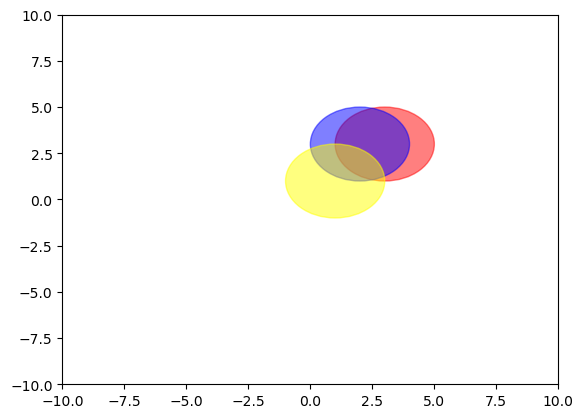

In [3]:
from matplotlib.patches import Ellipse
import matplotlib.patches as pth
import math as m

class AstroEllipse(Ellipse):
    pi = m.pi
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      assert(semi_major >= semi_minor)
      self.x_c = xc
      self.y_c = yc
      self.ang = position_angle  
      self.sm_maj = semi_major
      self.sm_min = semi_minor  
      XY = (xc, yc)                 
      angle_mpl = position_angle     
      height = 2.0*semi_major        
      width  = 2.0*semi_minor        
      super().__init__(XY, width, height, angle=angle_mpl, **args)
    def area(self):
        ar = self.sm_min*self.sm_maj*self.pi
        return ar
    def perimeter(self):
        pr = self.pi*(3*(self.sm_maj+self.sm_min) - m.sqrt((3*self.sm_maj + self.sm_min)*(self.sm_maj + 3*self.sm_min)))
        return pr
    def __str__(self):
        fstring = f'({self.x_c}, {self.y_c}) is the center, {self.ang} is the angle'
        return fstring


ell1 = AstroEllipse(0, 0, 3, 2, 0)
a_r = ell1.area()
p_r = ell1.perimeter()
print(ell1.__str__())
print(a_r, p_r)



class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius):
        return xc




fig, ax = plt.subplots(1)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
circ1 = pth.Circle((np.random.randint(0, 5), np.random.randint(0,5)), radius = np.random.randint(0, 5), color = 'red', alpha = 0.5)
circ2 = pth.Circle((np.random.randint(0, 5), np.random.randint(0,5)), radius = np.random.randint(0, 5), color = 'blue', alpha = 0.5)
circ3 = pth.Circle((np.random.randint(0, 5), np.random.randint(0,5)), radius = np.random.randint(0, 5), color = 'yellow', alpha = 0.5)
ax.add_patch(circ1)
ax.add_patch(circ2)
ax.add_patch(circ3)
plt.show()

In [80]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

NameError: name 'totalpoints' is not defined

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

Text(0.5, 0.98, 'Bessel Functions on the interval [0,10]')

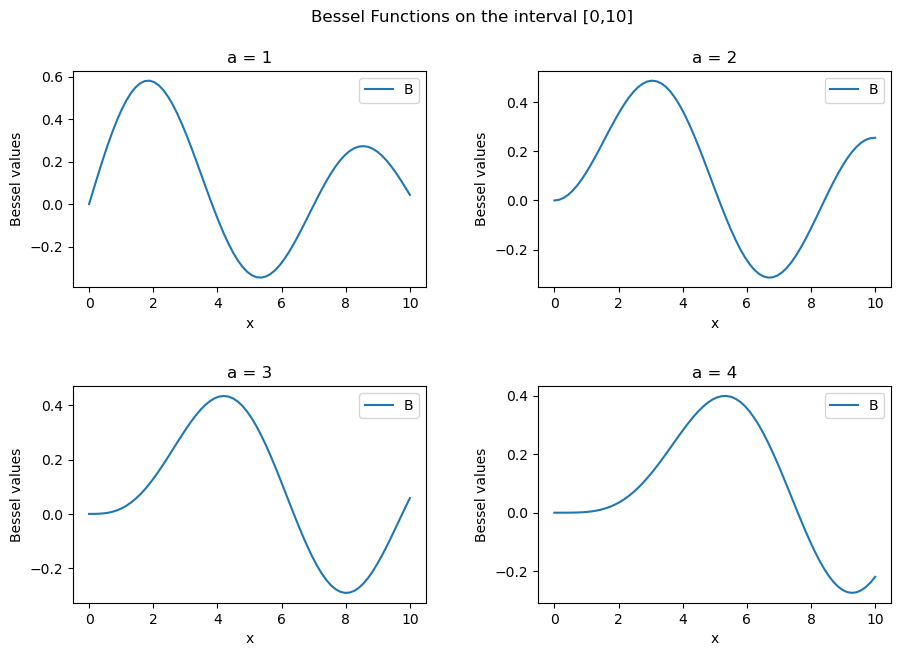

In [24]:
from scipy.special import jv
import matplotlib.pyplot as plt
import numpy as np

class Bessel:
    def __init__(self, a, x):
        self.a = a
        self.x = x
    def jv(self):
        return jv(self.a, self.x)
  #def plotting(self):
        #fig = plt.figure(figsize = (8,6))
        #ax_array = fig.subplots(2, 2, squeeze = 'False')
        #fig.tight_layout(pad=5.0)
        #ax_array[0,0].plot(x, Bessel.jv(self))
        #ax_array[0,0].set_xlabel('x values')
        #ax_array[0,0].set_ylabel('Bessel function')  
        #ax_array[0,0].legend('B')
        #fig.suptitle('Bessel Functions on the interval [0,10]')
        
#i didnt know exactly how to use oop for this; above is my attempt, could you give me a hint in the feedback?

        

x = np.linspace(0, 10, num = 70)
bes, bes2, bes3, bes4 = Bessel(1, x), Bessel(2, x), Bessel(3, x), Bessel(4, x)


fig = plt.figure(figsize = (10,7))
ax_array = fig.subplots(2, 2)
fig.tight_layout(pad=5.0)

ax_array[0,0].plot(x, bes.jv())
ax_array[0,0].set_xlabel('x')
ax_array[0,0].set_ylabel('Bessel values')
ax_array[0,0].set_title('a = 1')
ax_array[0,0].legend('B1')

ax_array[0,1].plot(x, bes2.jv())
ax_array[0,1].set_xlabel('x')
ax_array[0,1].set_ylabel('Bessel values')
ax_array[0,1].set_title('a = 2')
ax_array[0,1].legend('B2')

ax_array[1,0].plot(x, bes3.jv())
ax_array[1,0].set_xlabel('x')
ax_array[1,0].set_ylabel('Bessel values')
ax_array[1,0].set_title('a = 3')
ax_array[1,0].legend('B3')

ax_array[1,1].plot(x, bes4.jv())
ax_array[1,1].set_xlabel('x')
ax_array[1,1].set_ylabel('Bessel values')
ax_array[1,1].set_title('a = 4')
ax_array[1,1].legend('B4')



fig.suptitle('Bessel Functions on the interval [0,10]')




In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

Text(0.5, 1.0, 'Plot of Velocity versus distance')

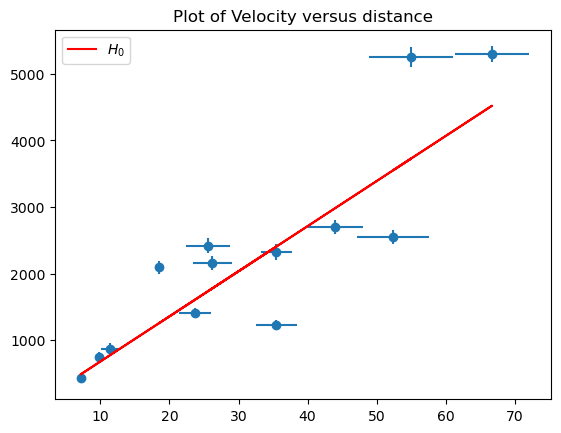

In [34]:
import matplotlib.pyplot as plt
import numpy as np
data = np.array([
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ])

data_new = data.reshape(13, 4)
d = data_new[:,0]
v = data_new[:,1]
er_d = data_new[:,2]
er_v = data_new[:,3]

fig = plt.figure()
ax = fig.subplots()
ax.scatter(d, v)
ax.errorbar(d, v, er_v, er_d, fmt = 'None')
ax.plot(d, 67.8*d, label = '$H_0$', color = 'red')
ax.legend()
ax.set_title('Plot of Velocity versus distance')



In [31]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

NameError: name 'totalpoints' is not defined

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")